# Carbon-24 K-means Clustering Analysis (Memory Optimized)

**Dự án:** Phân cụm cấu trúc Carbon-24  
**Phương pháp:** K-means Clustering  
**Tối ưu:** Memory-efficient với sampling cho metrics

## Nội dung:
1. Load dữ liệu đã preprocessing
2. Khảo sát tổng quan
3. Xác định số cluster tối ưu (với sampling)
4. Thực hiện K-means clustering
5. Đánh giá kết quả
6. Phân tích clusters
7. Visualization (PCA, t-SNE)
8. Lưu kết quả


In [23]:
# Import libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    silhouette_samples
)

import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print(" Libraries imported successfully!")


 Libraries imported successfully!


## 1. Load Dữ Liệu Đã Preprocessing

In [24]:
# Load preprocessed data
data_path = 'carbon24_preprocessing_results/carbon24_feature_selected_standard.csv'
df = pd.read_csv(data_path)

print(f" Loaded: {df.shape}")
print(f" Samples: {len(df)}")
print(f" Features: {len(df.columns)}")

df.head()


 Loaded: (10153, 31)
 Samples: 10153
 Features: 31


,formula,elements,num_atoms,a,b,c,alpha,beta,gamma,angle_deviation,angle_std,space_group_number,space_group_symbol,crystal_system,symprec_used,min_bond_length,max_bond_length,bond_length_range,min_coordination,max_coordination,fraction_sp,fraction_other,row_index,split,source_file,material_id,relative_energy,volume_ratio,lattice_asymmetry,bond_complexity,hybridization_diversity
0,C,C,-0.896504,-0.528201,0.738689,-0.571066,-1.560016,-1.944031,-2.663564,3.445121,-0.588230,12,C2/m,monoclinic,0.0,1.259865,0.173175,-0.623928,1.368488,0.522265,-0.054055,-0.039636,0,train,huggingface,C-130499-1826-36,-0.449890,-0.798002,0.208107,-0.648042,-0.860595
1,C,C,0.220331,-0.511806,0.338174,0.083799,0.050702,-0.756736,-1.818219,0.172052,0.482420,12,C2/m,monoclinic,0.0,0.339011,0.445863,0.161915,1.368488,0.522265,-0.054055,-0.039636,1,train,huggingface,C-13904-4247-31,-0.598634,-1.078242,0.441402,0.093659,-0.860595
2,C,C,0.220331,-0.596470,0.469011,0.092006,1.543116,0.765592,-0.787466,0.743753,1.349963,1,P1,triclinic,0.0,0.791188,-0.020574,-0.498651,-0.708382,0.522265,-0.054055,-0.039636,2,train,huggingface,C-92138-4782-35,0.530375,-0.778457,0.589175,-0.500065,0.806312
3,C,C,3.012419,-0.537603,-0.093448,3.347596,0.578627,-0.792132,0.042496,-0.891993,-0.220266,1,P1,triclinic,0.0,0.722778,0.819498,0.236920,1.368488,0.522265,-0.054055,-0.039636,3,train,huggingface,C-192672-505-73,-0.431188,-1.207221,2.398156,-0.091224,-0.860595
4,C,C,-0.896504,1.078734,0.488669,-1.345514,1.167933,2.491922,-0.658669,1.603907,1.885853,2,P-1,triclinic,0.0,-0.733762,-1.406420,-0.715048,-0.708382,-1.867352,-0.054055,-0.039636,4,train,huggingface,C-193956-5355-22,0.796611,1.275598,-1.325352,-0.653895,-0.860595


## 2. Khảo Sát Tổng Quan

In [25]:
# Load feature list
with open('carbon24_preprocessing_results/selected_features.json', 'r') as f:
    feature_info = json.load(f)

numeric_features = feature_info['numeric_features']
categorical_features = feature_info['categorical_features']

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"\nNumeric features for clustering:")
for feat in numeric_features:
    print(f"  - {feat}")


Numeric features: 22
Categorical features: 7

Numeric features for clustering:
  - num_atoms
  - a
  - b
  - c
  - alpha
  - beta
  - gamma
  - angle_deviation
  - angle_std
  - symprec_used
  - min_bond_length
  - max_bond_length
  - bond_length_range
  - min_coordination
  - max_coordination
  - fraction_sp
  - fraction_other
  - relative_energy
  - volume_ratio
  - lattice_asymmetry
  - bond_complexity
  - hybridization_diversity


In [26]:
# Dataset info
print("Dataset Information:")
print("="*80)
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.info()


Dataset Information:
Shape: (10153, 31)
Memory usage: 5.63 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10153 entries, 0 to 10152
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   formula                  10153 non-null  object 
 1   elements                 10153 non-null  object 
 2   num_atoms                10153 non-null  float64
 3   a                        10153 non-null  float64
 4   b                        10153 non-null  float64
 5   c                        10153 non-null  float64
 6   alpha                    10153 non-null  float64
 7   beta                     10153 non-null  float64
 8   gamma                    10153 non-null  float64
 9   angle_deviation          10153 non-null  float64
 10  angle_std                10153 non-null  float64
 11  space_group_number       10153 non-null  int64  
 12  space_group_symbol       10153 non-null  object 
 13  crystal_system

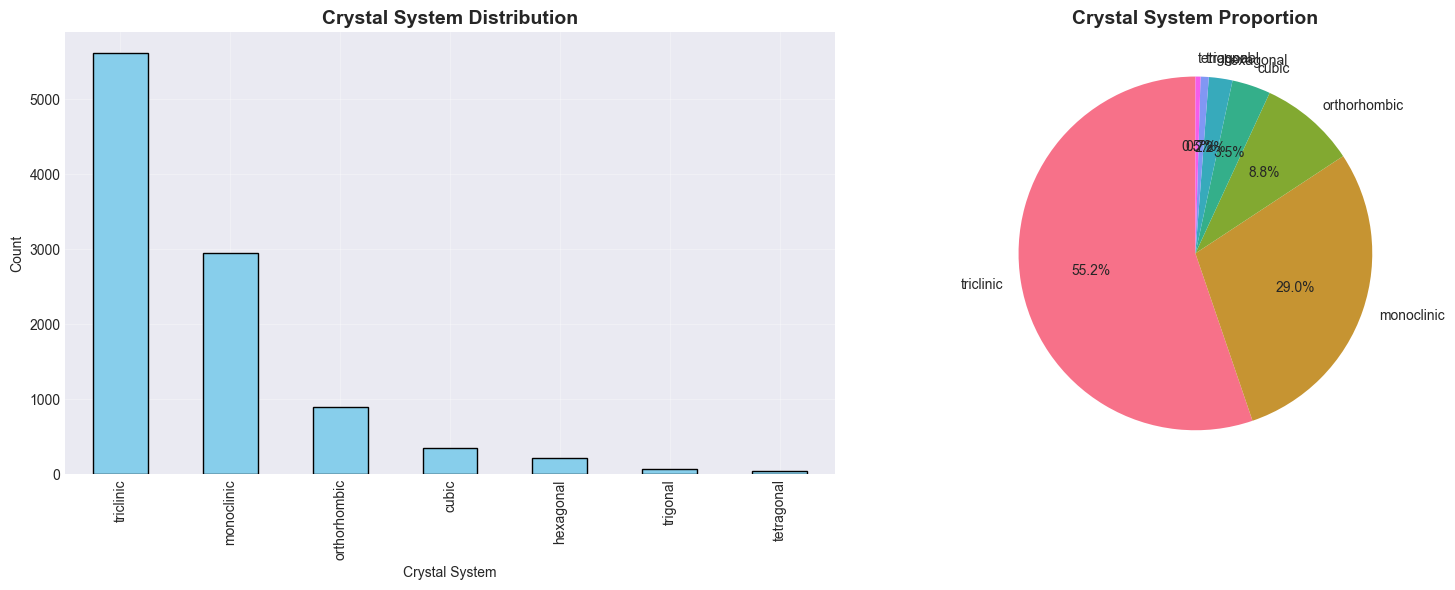

In [27]:
# Crystal system distribution
if 'crystal_system' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    crystal_counts = df['crystal_system'].value_counts()
    
    # Bar plot
    crystal_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('Crystal System Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Crystal System')
    axes[0].set_ylabel('Count')
    axes[0].grid(True, alpha=0.3)
    
    # Pie chart
    axes[1].pie(crystal_counts, labels=crystal_counts.index, autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette('husl', len(crystal_counts)))
    axes[1].set_title('Crystal System Proportion', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


## 3. Chuẩn Bị Dữ Liệu Cho Clustering

In [28]:
# Select features for clustering
X = df[numeric_features].copy()

print(f"Clustering data shape: {X.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Memory: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Verify data is normalized
print(f"\nData statistics:")
print(f"Mean: {X.mean().mean():.4f}")
print(f"Std: {X.std().mean():.4f}")


Clustering data shape: (10153, 22)
Features: 22
Samples: 10153
Memory: 1.70 MB

Data statistics:
Mean: -0.0000
Std: 0.9546


## Xác Định Số Cluster Tối Ưu - Elbow Method

Sử dụng **Elbow plot (SSE - Sum of Squared Errors)** để xác định điểm khuỷu tay (elbow point) - số cluster tối ưu.

In [29]:
# Prepare data for clustering
X = df[numeric_features].values

print(f"Data shape for clustering: {X.shape}")
print(f"Features: {len(numeric_features)}")
print(f"Samples: {len(X)}")

# Create output directory
os.makedirs('carbon24_kmeans_results', exist_ok=True)
os.makedirs('carbon24_kmeans_results/figures', exist_ok=True)

Data shape for clustering: (10153, 22)
Features: 22
Samples: 10153


In [30]:
# Elbow Method - Calculate SSE (Sum of Squared Errors) for different k values
print(" Calculating SSE for Elbow Method...")
print("="*80)

k_range = range(2, 11)  # Test k from 2 to 10
sse_values = []  # Sum of Squared Errors (Inertia)

for k in k_range:
    print(f"Testing k={k}...", end=' ')
    
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    
    kmeans.fit(X)
    sse_values.append(kmeans.inertia_)
    
    print(f"SSE = {kmeans.inertia_:.2f}")

print("\n SSE calculation completed!")

 Calculating SSE for Elbow Method...
Testing k=2... SSE = 172235.36
Testing k=3... SSE = 143893.03
Testing k=4... SSE = 132591.64
Testing k=5... SSE = 126552.28
Testing k=6... SSE = 119259.53
Testing k=7... SSE = 112651.04
Testing k=8... SSE = 108418.23
Testing k=9... SSE = 101654.77
Testing k=10... SSE = 97198.09

 SSE calculation completed!


 Saved: carbon24_kmeans_results/figures/kmeans_elbow_plot.png


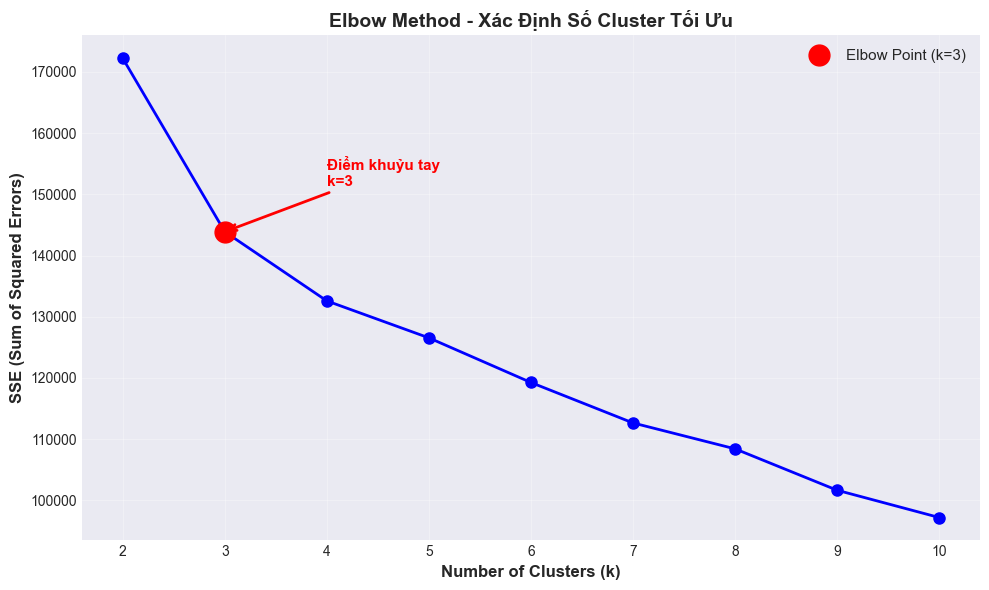


 SSE Values:
k= 2: SSE = 172,235.36
k= 3: SSE = 143,893.03 ← Elbow Point
k= 4: SSE = 132,591.64
k= 5: SSE = 126,552.28
k= 6: SSE = 119,259.53
k= 7: SSE = 112,651.04
k= 8: SSE = 108,418.23
k= 9: SSE = 101,654.77
k=10: SSE = 97,198.09


In [31]:
# Plot Elbow curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_range, sse_values, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('SSE (Sum of Squared Errors)', fontsize=12, fontweight='bold')
ax.set_title('Elbow Method - Xác Định Số Cluster Tối Ưu', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_range)

# Highlight the elbow point (k=3 based on previous analysis)
elbow_k = 3
elbow_sse = sse_values[elbow_k - 2]  # Index adjustment
ax.plot(elbow_k, elbow_sse, 'ro', markersize=15, label=f'Elbow Point (k={elbow_k})')
ax.annotate(
    f'Điểm khuỷu tay\nk={elbow_k}',
    xy=(elbow_k, elbow_sse),
    xytext=(elbow_k + 1, elbow_sse + (max(sse_values) - min(sse_values)) * 0.1),
    arrowprops=dict(arrowstyle='->', color='red', lw=2),
    fontsize=11,
    fontweight='bold',
    color='red'
)

ax.legend(fontsize=11)
plt.tight_layout()

# Save figure
plt.savefig('carbon24_kmeans_results/figures/kmeans_elbow_plot.png', dpi=300, bbox_inches='tight')
print(" Saved: carbon24_kmeans_results/figures/kmeans_elbow_plot.png")

plt.show()

# Print SSE values
print("\n SSE Values:")
print("="*40)
for k, sse in zip(k_range, sse_values):
    marker = " ← Elbow Point" if k == elbow_k else ""
    print(f"k={k:2d}: SSE = {sse:,.2f}{marker}")

### 📊 Phân Tích Elbow Plot

**Cách đọc Elbow plot:**
- **Trục X**: Số lượng clusters (k)
- **Trục Y**: SSE (Sum of Squared Errors) - Tổng bình phương khoảng cách từ mỗi điểm đến cluster center
- **Điểm khuỷu tay (Elbow Point)**: Điểm mà SSE giảm chậm lại đáng kể

**Giải thích:**
- SSE luôn giảm khi tăng k (càng nhiều clusters, điểm càng gần centers)
- Nhưng không nên chọn k quá lớn (overfitting)
- **Elbow point** là điểm cân bằng tốt nhất: giảm SSE đáng kể nhưng không quá phức tạp

**Kết luận:**
- Từ Elbow plot, **k=3** là lựa chọn tối ưu
- Tại k=3, SSE giảm mạnh so với k=2
- Sau k=3, SSE giảm chậm hơn → không cần thiết phải tăng k

## 4. Xác Định Số Cluster Tối Ưu (Memory Optimized)

**Tối ưu hóa:** Sử dụng sampling cho Silhouette score để tiết kiệm bộ nhớ.


In [19]:
# Elbow method with sampling for silhouette
k_range = range(2, 21)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

# Sample size for silhouette (to save memory)
SAMPLE_SIZE = min(5000, len(X))  # Use max 5000 samples for silhouette
print(f"Using sample size: {SAMPLE_SIZE} for Silhouette score calculation")

print("\nTesting different k values...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    
    # Use sampling for silhouette score to save memory
    silhouette_scores.append(silhouette_score(X, labels, sample_size=SAMPLE_SIZE))
    
    # These metrics don't require pairwise distances
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X, labels))
    
    if k % 5 == 0:
        print(f"  k={k}: Silhouette={silhouette_scores[-1]:.4f}, DB={davies_bouldin_scores[-1]:.4f}")

print("\n Completed!")


Using sample size: 5000 for Silhouette score calculation

Testing different k values...
  k=5: Silhouette=0.2088, DB=1.8296
  k=10: Silhouette=0.1540, DB=1.7936
  k=15: Silhouette=0.1475, DB=1.7672
  k=20: Silhouette=0.1337, DB=1.7075

 Completed!


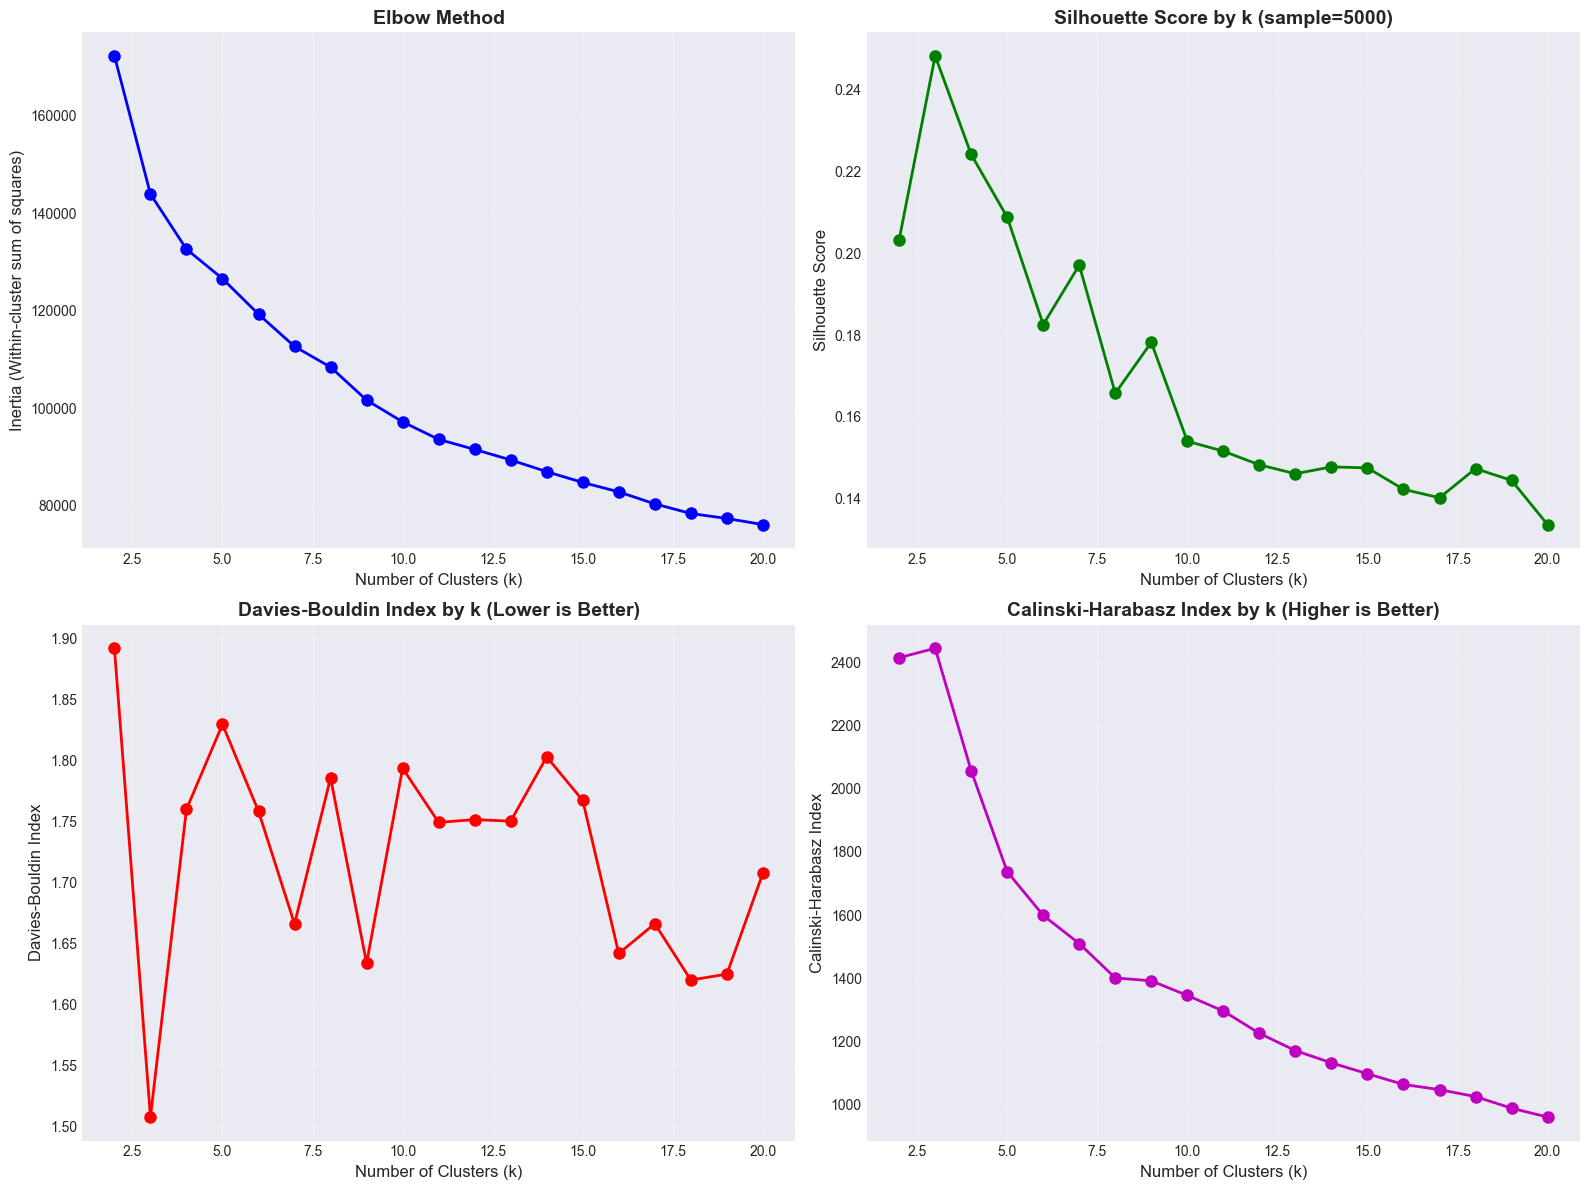

In [20]:
# Plot elbow curve
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Inertia (Elbow)
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score (higher is better)
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title(f'Silhouette Score by k (sample={SAMPLE_SIZE})', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Davies-Bouldin Index (lower is better)
axes[1, 0].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index by k (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Calinski-Harabasz Index (higher is better)
axes[1, 1].plot(k_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Index', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Index by k (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:
# Find optimal k
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_k_davies = k_range[np.argmin(davies_bouldin_scores)]
best_k_calinski = k_range[np.argmax(calinski_harabasz_scores)]

print("Optimal k by different metrics:")
print(f"  - Silhouette Score: k = {best_k_silhouette} (score: {max(silhouette_scores):.4f})")
print(f"  - Davies-Bouldin: k = {best_k_davies} (score: {min(davies_bouldin_scores):.4f})")
print(f"  - Calinski-Harabasz: k = {best_k_calinski} (score: {max(calinski_harabasz_scores):.2f})")

# Recommend k
recommended_k = best_k_silhouette
print(f"\n Recommended k: {recommended_k}")


Optimal k by different metrics:
  - Silhouette Score: k = 3 (score: 0.2483)
  - Davies-Bouldin: k = 3 (score: 1.5076)
  - Calinski-Harabasz: k = 3 (score: 2444.86)

 Recommended k: 3


## 5. Thực Hiện K-means Clustering

In [22]:
# Perform K-means with optimal k
optimal_k = recommended_k  # You can change this value

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X)

# Add cluster labels to dataframe
df['cluster'] = cluster_labels

print(f" K-means clustering completed with k={optimal_k}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())


 K-means clustering completed with k=3

Cluster distribution:
cluster
0    3402
1    2228
2    4523
Name: count, dtype: int64


In [23]:
# Clustering metrics (with sampling for silhouette)
silhouette_avg = silhouette_score(X, cluster_labels, sample_size=SAMPLE_SIZE)
davies_bouldin = davies_bouldin_score(X, cluster_labels)
calinski_harabasz = calinski_harabasz_score(X, cluster_labels)

print("Clustering Quality Metrics:")
print("="*60)
print(f"Silhouette Score: {silhouette_avg:.4f} (sample={SAMPLE_SIZE})")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f} (lower is better)")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.2f} (higher is better)")
print(f"Inertia: {kmeans_final.inertia_:.2f}")


Clustering Quality Metrics:
Silhouette Score: 0.2479 (sample=5000)
Davies-Bouldin Index: 1.5076 (lower is better)
Calinski-Harabasz Index: 2444.86 (higher is better)
Inertia: 143893.03


## 6. Phân Tích Clusters

In [24]:
# Cluster statistics
cluster_stats = df.groupby('cluster')[numeric_features].mean()

print("Cluster Centers (mean values):")
display(cluster_stats.round(4))


Cluster Centers (mean values):


,num_atoms,a,b,c,alpha,beta,gamma,angle_deviation,angle_std,symprec_used,min_bond_length,max_bond_length,bond_length_range,min_coordination,max_coordination,fraction_sp,fraction_other,relative_energy,volume_ratio,lattice_asymmetry,bond_complexity,hybridization_diversity
cluster,,,,,,,,,,,,,,,,,,,,,,
0,-0.2598,-0.0532,-0.2421,-0.4125,-0.0270,-0.0334,-0.0231,0.0623,0.0542,0.0,1.2084,0.3153,-0.4752,1.3502,0.5223,-0.0541,-0.0396,-0.4792,-0.9417,-0.3368,-0.5396,-0.8444
1,-0.3737,0.4168,-0.2057,-0.0546,-0.0176,0.0254,0.0168,0.1617,0.0687,0.0,-0.4079,-1.4745,-0.9697,-0.7084,-1.8674,-0.0541,-0.0396,-0.3778,1.2599,-0.3362,-0.9917,-0.8606
2,0.3795,-0.1653,0.2835,0.3371,0.0290,0.0126,0.0091,-0.1265,-0.0746,0.0,-0.7080,0.4892,0.8351,-0.6666,0.5270,0.0673,0.0493,0.5465,0.0877,0.4190,0.8944,1.0590


In [25]:
# Cluster sizes and percentages
cluster_info = pd.DataFrame({
    'Size': df['cluster'].value_counts().sort_index(),
    'Percentage': (df['cluster'].value_counts().sort_index() / len(df) * 100).round(2)
})

print("Cluster Information:")
display(cluster_info)


Cluster Information:


,Size,Percentage
cluster,,
0,3402,33.51
1,2228,21.94
2,4523,44.55


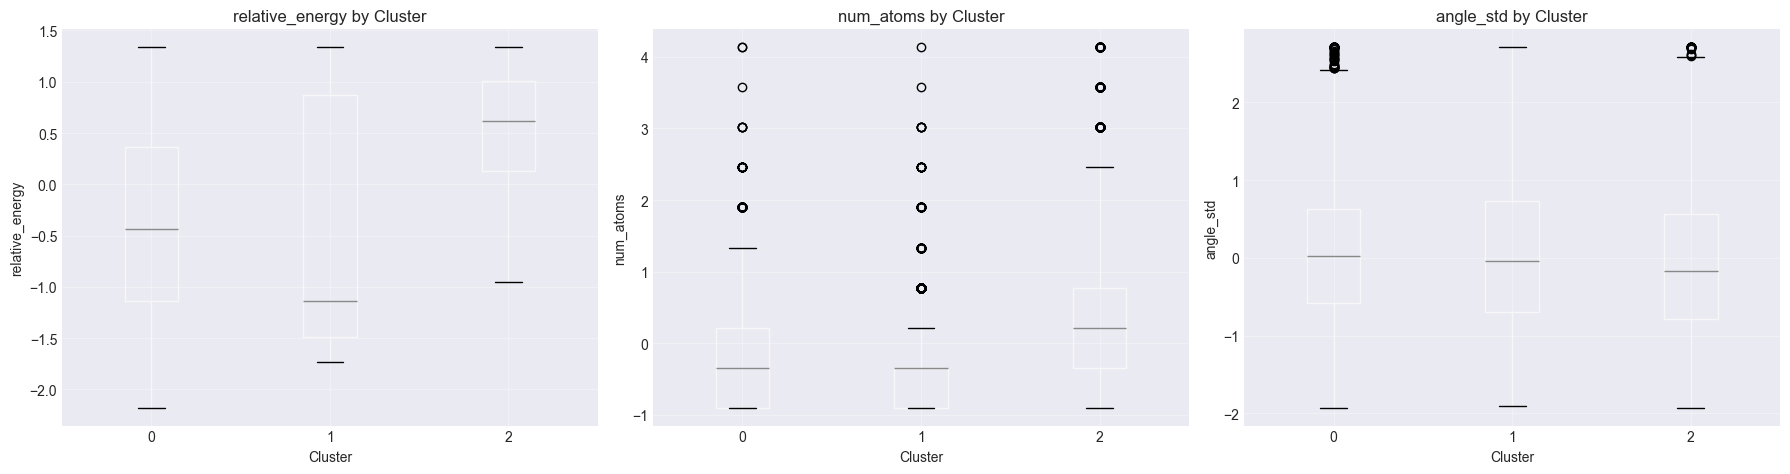

In [26]:
# Analyze key features by cluster
key_features_analysis = ['relative_energy', 'num_atoms', 'angle_std']

fig, axes = plt.subplots(1, len(key_features_analysis), figsize=(18, 5))

for idx, feature in enumerate(key_features_analysis):
    if feature in df.columns:
        df.boxplot(column=feature, by='cluster', ax=axes[idx])
        axes[idx].set_title(f'{feature} by Cluster')
        axes[idx].set_xlabel('Cluster')
        axes[idx].set_ylabel(feature)
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()


Crystal System Distribution by Cluster:


crystal_system,cubic,hexagonal,monoclinic,orthorhombic,tetragonal,triclinic,trigonal
cluster,,,,,,,
0,358,212,1179,581,47,957,68
1,0,7,567,34,0,1613,7
2,0,0,1202,282,0,3038,1



Percentage by Cluster:


crystal_system,cubic,hexagonal,monoclinic,orthorhombic,tetragonal,triclinic,trigonal
cluster,,,,,,,
0,10.52,6.23,34.66,17.08,1.38,28.13,2.00
1,0.00,0.31,25.45,1.53,0.00,72.40,0.31
2,0.00,0.00,26.58,6.23,0.00,67.17,0.02


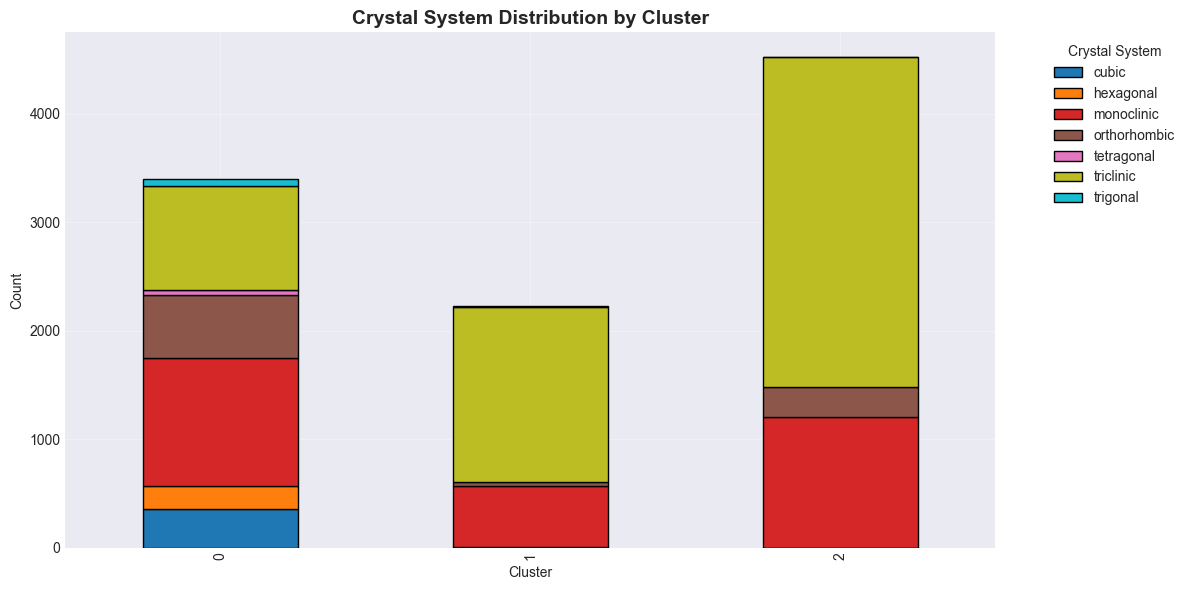

In [27]:
# Crystal system distribution by cluster
if 'crystal_system' in df.columns:
    crystal_cluster = pd.crosstab(df['cluster'], df['crystal_system'])
    
    print("Crystal System Distribution by Cluster:")
    display(crystal_cluster)
    
    # Percentage
    crystal_cluster_pct = pd.crosstab(df['cluster'], df['crystal_system'], normalize='index') * 100
    print("\nPercentage by Cluster:")
    display(crystal_cluster_pct.round(2))
    
    # Visualization
    crystal_cluster.plot(kind='bar', stacked=True, figsize=(12, 6), 
                         colormap='tab10', edgecolor='black')
    plt.title('Crystal System Distribution by Cluster', fontsize=14, fontweight='bold')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.legend(title='Crystal System', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7. Visualization

### 7.1 PCA Visualization


In [28]:
# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f}")

# Add PCA components to dataframe
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]


PCA explained variance ratio:
  PC1: 0.2457
  PC2: 0.1538
  Total: 0.3995


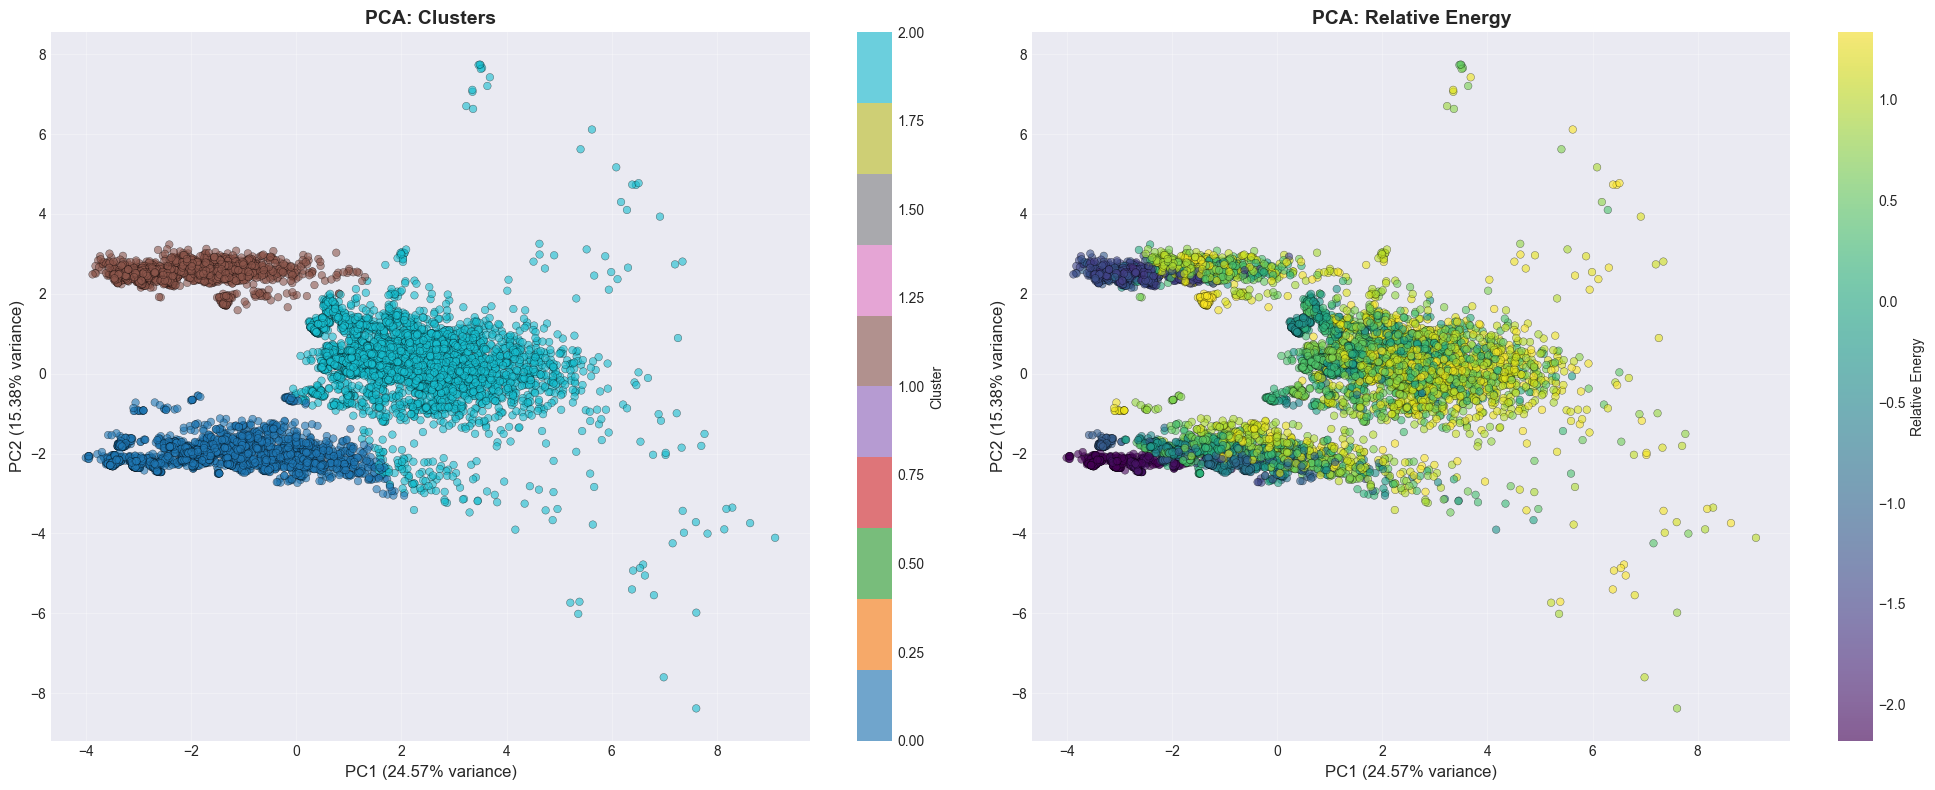

In [29]:
# Plot PCA with clusters
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# By cluster
scatter1 = axes[0].scatter(df['pca1'], df['pca2'], c=df['cluster'], 
                           cmap='tab10', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
axes[0].set_title('PCA: Clusters', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# By relative energy
if 'relative_energy' in df.columns:
    scatter2 = axes[1].scatter(df['pca1'], df['pca2'], c=df['relative_energy'],
                               cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    axes[1].set_title('PCA: Relative Energy', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Relative Energy')

plt.tight_layout()
plt.show()


### 7.2 t-SNE Visualization (Optional - Memory Intensive)

**Note:** t-SNE có thể tốn nhiều bộ nhớ. Nếu gặp lỗi, hãy skip cell này.


Sampling 5000 points for t-SNE...
Computing t-SNE... (this may take a while)


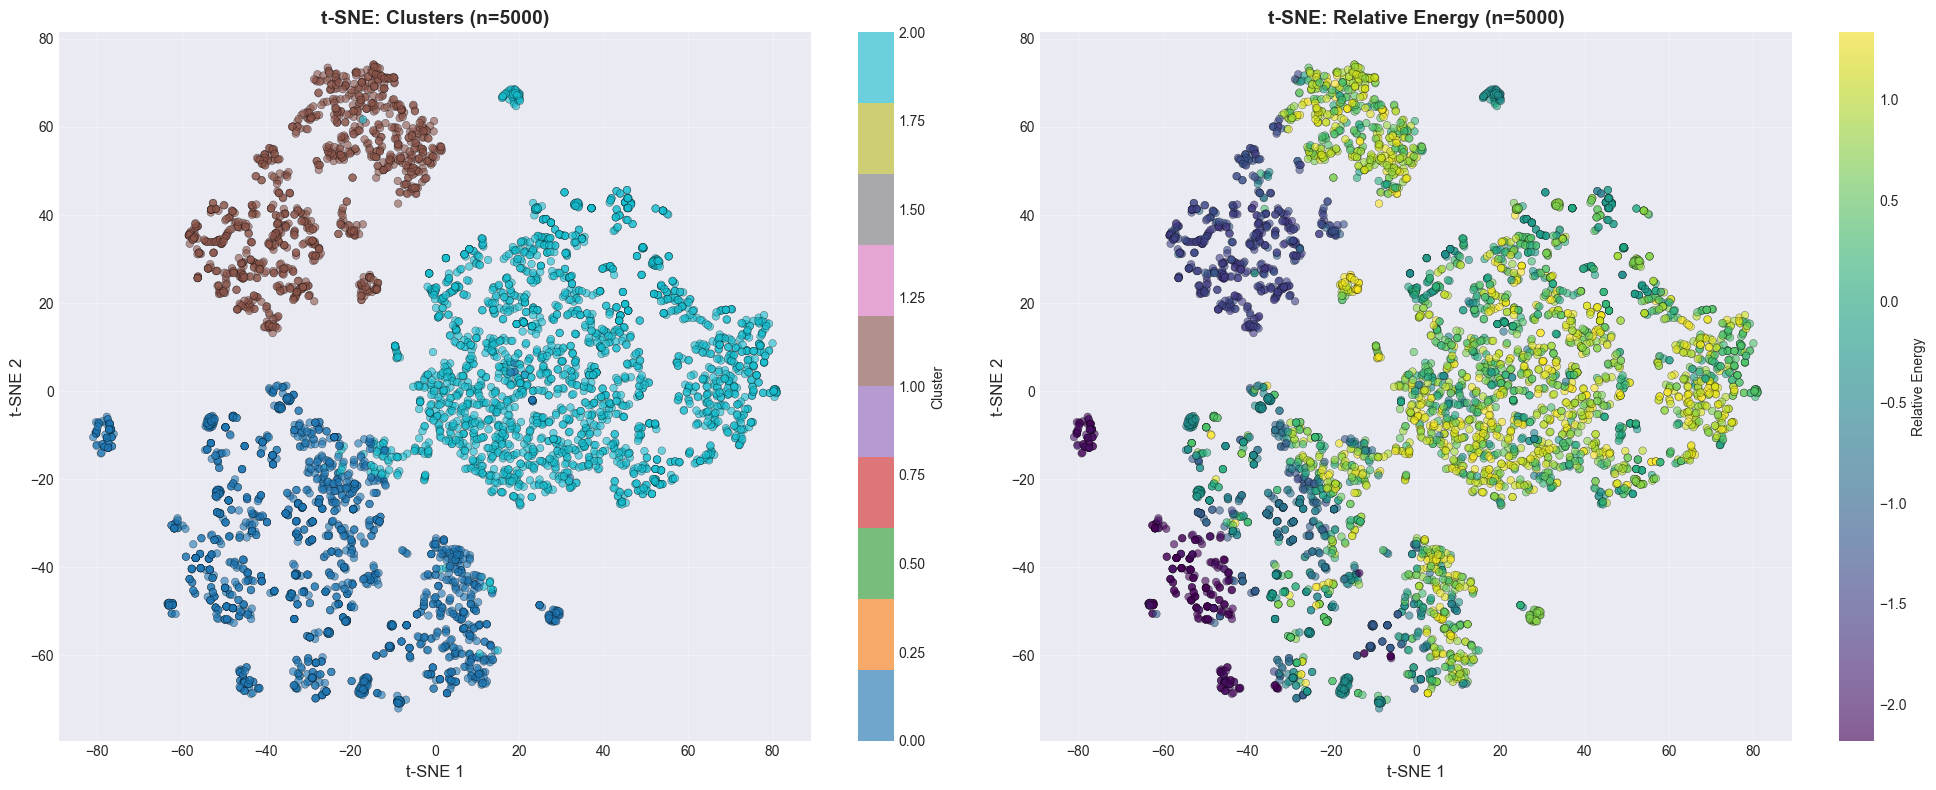

 t-SNE completed!


In [31]:
# t-SNE with sampling if dataset is large
USE_TSNE = True  # Set to False to skip t-SNE

if USE_TSNE:
    # Sample data if too large
    tsne_sample_size = min(5000, len(X))
    
    if tsne_sample_size < len(X):
        print(f"Sampling {tsne_sample_size} points for t-SNE...")
        sample_idx = np.random.choice(len(X), tsne_sample_size, replace=False)
        X_tsne_input = X.iloc[sample_idx]
        df_tsne = df.iloc[sample_idx].copy()
    else:
        X_tsne_input = X
        df_tsne = df.copy()
    
    print("Computing t-SNE... (this may take a while)")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

    X_tsne = tsne.fit_transform(X_tsne_input)
    
    df_tsne['tsne1'] = X_tsne[:, 0]
    df_tsne['tsne2'] = X_tsne[:, 1]
    
    # Plot t-SNE
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # By cluster
    scatter1 = axes[0].scatter(df_tsne['tsne1'], df_tsne['tsne2'], c=df_tsne['cluster'],
                               cmap='tab10', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
    axes[0].set_xlabel('t-SNE 1', fontsize=12)
    axes[0].set_ylabel('t-SNE 2', fontsize=12)
    axes[0].set_title(f't-SNE: Clusters (n={len(df_tsne)})', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='Cluster')
    
    # By relative energy
    if 'relative_energy' in df_tsne.columns:
        scatter2 = axes[1].scatter(df_tsne['tsne1'], df_tsne['tsne2'], c=df_tsne['relative_energy'],
                                   cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
        axes[1].set_xlabel('t-SNE 1', fontsize=12)
        axes[1].set_ylabel('t-SNE 2', fontsize=12)
        axes[1].set_title(f't-SNE: Relative Energy (n={len(df_tsne)})', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        plt.colorbar(scatter2, ax=axes[1], label='Relative Energy')
    
    plt.tight_layout()
    plt.show()
    
    print(" t-SNE completed!")
else:
    print("t-SNE skipped (set USE_TSNE=True to enable)")


## 8. Lưu Kết Quả

In [32]:
# Create output directory
output_dir = 'carbon24_kmeans_results'
os.makedirs(output_dir, exist_ok=True)

# Save clustered data
df.to_csv(f'{output_dir}/carbon24_clustered.csv', index=False)
print(f" Saved: {output_dir}/carbon24_clustered.csv")

# Save cluster centers
cluster_centers_df = pd.DataFrame(kmeans_final.cluster_centers_, columns=numeric_features)
cluster_centers_df.to_csv(f'{output_dir}/cluster_centers.csv', index=False)
print(f" Saved: {output_dir}/cluster_centers.csv")

# Save cluster statistics
cluster_stats.to_csv(f'{output_dir}/cluster_statistics.csv')
print(f" Saved: {output_dir}/cluster_statistics.csv")


 Saved: carbon24_kmeans_results/carbon24_clustered.csv
 Saved: carbon24_kmeans_results/cluster_centers.csv
 Saved: carbon24_kmeans_results/cluster_statistics.csv


In [33]:
# Save clustering report
report = {
    'optimal_k': int(optimal_k),
    'n_samples': len(df),
    'n_features': len(numeric_features),
    'sample_size_for_silhouette': SAMPLE_SIZE,
    'metrics': {
        'silhouette_score': float(silhouette_avg),
        'davies_bouldin_index': float(davies_bouldin),
        'calinski_harabasz_index': float(calinski_harabasz),
        'inertia': float(kmeans_final.inertia_)
    },
    'cluster_sizes': df['cluster'].value_counts().sort_index().to_dict(),
    'pca_variance_explained': {
        'pc1': float(pca.explained_variance_ratio_[0]),
        'pc2': float(pca.explained_variance_ratio_[1]),
        'total': float(pca.explained_variance_ratio_.sum())
    }
}

with open(f'{output_dir}/clustering_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f" Saved: {output_dir}/clustering_report.json")


 Saved: carbon24_kmeans_results/clustering_report.json


##  Summary

### Clustering Results:
- **Dataset:** 10,153 samples × 22 features
- **Optimal k:** (see above)
- **Silhouette Score:** (sampled)
- **Davies-Bouldin Index:** (lower is better)
- **Calinski-Harabasz Index:** (higher is better)

### Memory Optimization:
-  Sampling for Silhouette score calculation
-  Reduced marker size in plots
-  Optional t-SNE with sampling

### Output Files:
- `carbon24_kmeans_results/carbon24_clustered.csv` - Data with cluster labels
- `carbon24_kmeans_results/cluster_centers.csv` - Cluster centers
- `carbon24_kmeans_results/cluster_statistics.csv` - Cluster statistics
- `carbon24_kmeans_results/clustering_report.json` - Detailed report

### Next Steps:
-  Anomaly Detection (Isolation Forest, LOF)
-  Energy Prediction (Regression models)
-  Advanced Visualization
-  Cluster Interpretation
